In [1]:
#IMPORT PACKAGES
import torch 
import lightning 
import numpy as np 
import matplotlib.pyplot as plt

#IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

#Set seed for reproducibility
torch.manual_seed(42)

In [7]:
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule
#from deeptime.covariance import KoopmanWeightingEstimator

filenames = [ "COLVAR_driver" ]

# load file
df = load_dataframe(filenames,start=0,stop=1000000,stride=1)

# get descriptors
X = df.filter(regex='cos|sin').values

#get time
t = df['time'].values

#lag_time
lag_time = 10

# build time-lagged dataset (composed by pairs of configs at time t, t+lag)
dataset = create_timelagged_dataset(X,t,lag_time=lag_time,logweights=None)

# create datamodule
datamodule = DictModule(dataset,lengths=[0.8,0.2])#,random_split=False,shuffle=False)

print(X.shape)

/home/revanth/.local/lib/python3.10/site-packages/mlcolvar/utils/timelagged.py:140: UserWarning: Monitoring the progress for the search of time-lagged configurations with a progress_bar requires `tqdm`.
  warnings.warn(


(1000000, 40)


In [8]:
df.filter(regex='cos')

,cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20
0,0.285590,-0.721518,0.008732,0.526282,-0.057145,0.787507,0.666040,0.778023,0.946940,0.976450,-0.347408,-0.998882,0.594234,-0.826208,0.558543,0.949088,0.808431,0.802743,0.902256,0.995918
1,0.669594,-0.724632,-0.094740,0.405426,-0.052137,0.933748,0.818761,0.818961,0.920345,0.999893,-0.814227,-0.999326,0.229797,-0.773444,0.410695,0.820205,0.717014,0.816399,0.950321,0.982609
2,0.431460,-0.810236,-0.153386,0.276626,-0.085335,0.988985,0.955568,0.947852,0.970993,0.997536,-0.241100,-0.974536,0.779584,-0.658702,0.407613,0.843856,0.717009,0.831545,0.952250,0.988395
3,0.448164,-0.844466,-0.057290,0.174948,-0.048876,0.907357,0.829328,0.855126,0.959820,0.995572,-0.544933,-0.968659,0.615739,-0.646350,0.099123,0.782687,0.742277,0.900238,0.997959,0.926625
4,0.556335,-0.908991,-0.175068,0.493461,0.272982,0.921021,0.787753,0.787842,0.905134,0.999554,-0.445208,-0.961606,0.510531,-0.650759,0.291293,0.858438,0.789729,0.862912,0.972088,0.981964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.535813,0.346908,-0.777490,0.393232,-0.999377,0.947712,0.983884,0.847342,0.709815,0.760428,0.316079,-0.996287,0.506462,-0.851427,-0.128301,0.999764,0.961039,0.900333,0.866854,0.943095
999996,0.662287,0.183346,-0.356009,0.406133,-0.979395,0.999811,0.941575,0.855131,0.839183,0.932699,0.540756,-0.951184,0.458452,-0.504204,-0.631054,0.867421,0.870837,0.951719,0.999816,0.951548
999997,0.777636,0.198625,-0.342454,0.344870,-0.993585,0.999700,0.927356,0.798351,0.806095,0.914292,0.694009,-0.805858,0.420207,-0.638893,-0.610859,0.812286,0.769399,0.878074,0.989751,0.965545
999998,0.512041,-0.069447,-0.478886,0.453687,-0.889087,0.971716,0.822395,0.728726,0.812018,0.970086,0.231120,-0.992927,0.386055,-0.793957,-0.327941,0.994591,0.923427,0.875481,0.902608,0.975438


(1000000, 40)
(1000000,)


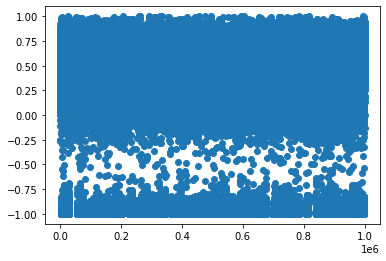

In [9]:
print(X.shape)
print(t.shape)


import matplotlib.pyplot as plt
plt.scatter(t,df['cos1'])

In [10]:
from mlcolvar.cvs import DeepTICA

n_components = 2
nn_layers = [40, 24, 12, 5]
options= {'nn': {'activation': 'shifted_softplus'} }

model = DeepTICA(nn_layers, n_cvs=n_components, options=options)
#model.loss_fn.n_eig = n_components

model

DeepTICA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=40, out_features=40, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=40, out_features=24, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=24, out_features=12, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=12, out_features=5, bias=True)
    )
  )
  (tica): TICA(in_features=5, out_features=2)
)

In [11]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=1e-5, patience=100)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=None, logger=None, enable_checkpointing=False)

# fit
torch.set_float32_matmul_precision('medium')
trainer.fit( model, datamodule )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/revanth/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/revanth/.local/lib/python3.10/site-packages/lightning/pytorch/lo

Sanity Checking: |                                                                                            …

/home/revanth/.local/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=1000` reached.


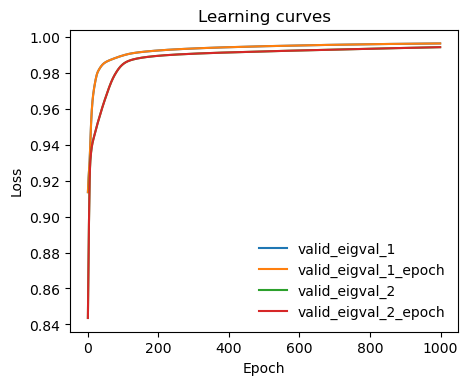

In [12]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics,
                  keys=[x for x in  metrics.metrics.keys() if 'valid_eigval' in x],#['train_loss_epoch','valid_loss'],
                  #linestyles=['-.','-'], colors=['fessa1','fessa5'],
                  yscale='linear')

In [13]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

Text(0, 0.5, 'Deep-TICA 2')

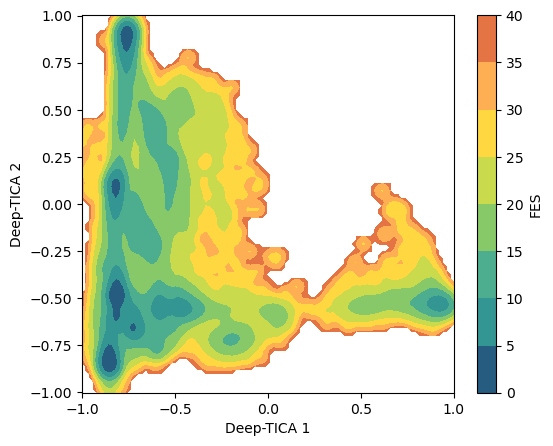

In [14]:
from mlcolvar.utils.fes import compute_fes

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()

#w = np.exp(logweights)
fes,grid,bounds,error = compute_fes(s[:,:2],
                                    blocks=1,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=40, ax = ax, eps=1e-10)

ax.set_xlabel('Deep-TICA 1')
ax.set_ylabel('Deep-TICA 2')

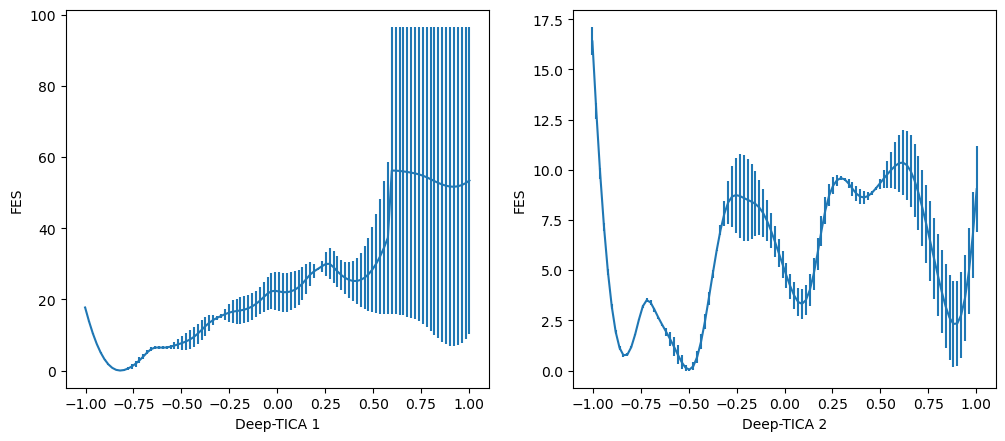

In [15]:
from mlcolvar.utils.fes import compute_fes

fig,axs = plt.subplots(1,n_components,figsize=(6*n_components,5),dpi=100)
if n_components == 1:
    axs = [axs]

for i in range(n_components):
    # restrict the second CV to the points in which the first is < 0
    fes,grid,bounds,error = compute_fes(s[:,i],
                                        blocks=2,
                                        bandwidth=0.02,scale_by='range',
                                        plot=True, plot_max_fes=100, ax = axs[i])
    axs[i].set_xlabel('Deep-TICA '+str(i+1))

In [19]:
#ElasticNet Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import ElasticNetCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic0 = s[:,0]#select DeepTICA 1

reg0 = ElasticNetCV(cv=5, random_state=0, max_iter=10000).fit(X, tic0)
print(reg0.coef_)
print(reg0.intercept_)
#np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[-2.74571520e-03  1.79903809e-02 -1.10146995e-02 -6.70076156e-03
  1.08042014e-01 -4.75301082e-02 -6.59988547e-02  1.21499051e-01
 -9.86918703e-03 -1.13243496e-02 -0.00000000e+00 -5.28797410e-03
 -1.39825570e-02  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
  4.39149768e-02  1.42793341e-02 -1.79753133e-01 -1.16091577e-01
 -5.41211792e-01 -2.11670465e-01 -8.88288681e-05  8.93795168e-04
  4.25211914e-03  3.95080689e-02  0.00000000e+00 -3.28095374e-04
  8.64026112e-02 -0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00  0.00000000e+00  8.45471266e-02]
-0.41113638993758017


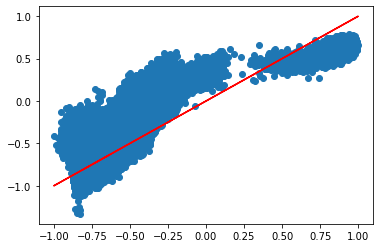

In [20]:
X_np = torch.Tensor(X).numpy()
ypred = reg0.predict(X)

plt.scatter(tic0,ypred)
plt.plot(tic0,tic0,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

In [24]:
features = []
for i in range(20):
    features.append(f"cos{i+1}")
    features.append(f"sin{i+1}")
features
    

['cos1',
 'sin1',
 'cos2',
 'sin2',
 'cos3',
 'sin3',
 'cos4',
 'sin4',
 'cos5',
 'sin5',
 'cos6',
 'sin6',
 'cos7',
 'sin7',
 'cos8',
 'sin8',
 'cos9',
 'sin9',
 'cos10',
 'sin10',
 'cos11',
 'sin11',
 'cos12',
 'sin12',
 'cos13',
 'sin13',
 'cos14',
 'sin14',
 'cos15',
 'sin15',
 'cos16',
 'sin16',
 'cos17',
 'sin17',
 'cos18',
 'sin18',
 'cos19',
 'sin19',
 'cos20',
 'sin20']

In [27]:
s='ElasticNet_node0: COMBINE ARG='
for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= features[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= '%0.4f'%reg0.coef_[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg0.coef_)
offset = reg0.intercept_
if offset>0:
    s2 = 'ElasticNetCV_node0: MATHEVAL ARG=ElasticNet_node0 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'ElasticNetCV_node0: MATHEVAL ARG=ElasticNet_node0 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

ElasticNet_node0: COMBINE ARG=cos1,sin1,cos2,sin2,cos3,sin3,cos4,sin4,cos5,sin5,sin6,cos7,cos11,sin11,cos12,sin12,cos13,sin13,cos14,sin14,cos15,sin15,sin16,cos17,sin20 COEFFICIENTS=-0.0027,0.0180,-0.0110,-0.0067,0.1080,-0.0475,-0.0660,0.1215,-0.0099,-0.0113,-0.0053,-0.0140,0.0439,0.0143,-0.1798,-0.1161,-0.5412,-0.2117,-0.0001,0.0009,0.0043,0.0395,-0.0003,0.0864,0.0845 PERIODIC=NO
 
ElasticNetCV_node0: MATHEVAL ARG=ElasticNet_node0 FUNC=x-0.4111 PERIODIC=NO


In [28]:
#ElasticNet Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import ElasticNetCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic1 = s[:,1]#select DeepTICA 2

reg1 = ElasticNetCV(cv=5, random_state=0, max_iter=10000).fit(X, tic1)
print(reg1.coef_)
print(reg1.intercept_)
#np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[-0.         -0.0443813   0.0081472   0.         -0.          0.
  0.043958   -0.06025705 -0.29944254 -0.51520555  0.          0.
  0.         -0.          0.          0.05451568 -0.         -0.
 -0.          0.          0.          0.00645136  0.          0.
  0.          0.         -0.         -0.          0.03732445  0.23876737
 -0.         -0.         -0.          0.          0.         -0.00187092
  0.          0.         -0.         -0.        ]
-0.087367959946613


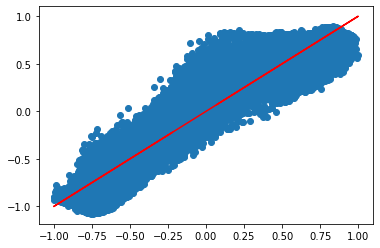

In [29]:
X_np = torch.Tensor(X).numpy()
ypred = reg1.predict(X)

plt.scatter(tic1,ypred)
plt.plot(tic1,tic1,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

In [31]:
s='ElasticNet_node1: COMBINE ARG='
for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= features[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= '%0.4f'%reg1.coef_[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg1.coef_)
offset = reg1.intercept_
if offset>0:
    s2 = 'ElasticNetCV_node1: MATHEVAL ARG=ElasticNet_node1 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'ElasticNetCV_node1: MATHEVAL ARG=ElasticNet_node1 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

ElasticNet_node1: COMBINE ARG=sin1,cos2,cos4,sin4,cos5,sin5,sin8,sin11,cos15,sin15,sin18, COEFFICIENTS=-0.0444,0.0081,0.0440,-0.0603,-0.2994,-0.5152,0.0545,0.0065,0.0373,0.2388,-0.0019, PERIODIC=NO
 
ElasticNetCV_node1: MATHEVAL ARG=ElasticNet_node1 FUNC=x-0.0874 PERIODIC=NO


In [32]:
model.to_torchscript(file_path='2ap_2ap_Deep_TICA_cos_sin_10ps.ptc', method='trace')

/home/revanth/.local/lib/python3.10/site-packages/mlcolvar/core/nn/utils.py:13: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  sp0 = F.softplus(torch.zeros(1), self.beta, self.threshold).item()


DeepTICA(
  original_name=DeepTICA
  (loss_fn): ReduceEigenvaluesLoss(original_name=ReduceEigenvaluesLoss)
  (norm_in): Normalization(original_name=Normalization)
  (nn): FeedForward(
    original_name=FeedForward
    (nn): Sequential(
      original_name=Sequential
      (0): Linear(original_name=Linear)
      (1): Shifted_Softplus(original_name=Shifted_Softplus)
      (2): Linear(original_name=Linear)
      (3): Shifted_Softplus(original_name=Shifted_Softplus)
      (4): Linear(original_name=Linear)
    )
  )
  (tica): TICA(original_name=TICA)
  (postprocessing): Normalization(original_name=Normalization)
)